<a href="https://colab.research.google.com/github/SamsondareHUB/YOLO-Blood-Cell-Detection/blob/main/yolov8-bccd-blood-cell-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.9 MB/s eta 0:00:00


In [ ]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])

import json
import logging
import random
import shutil
import time
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import torch
import ultralytics
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
WORK_DIR = Path("/content/bccd_yolov8")
RAW_DIR = WORK_DIR / "raw"
DATA_DIR = WORK_DIR / "dataset"
RUNS_DIR = WORK_DIR / "runs"
LOG_FILE = WORK_DIR / "experiment.log"
REPO_URL = "https://github.com/Shenggan/BCCD_Dataset.git"
CLASS_NAMES = ["RBC", "WBC", "Platelets"]
SEED = 42
EPOCHS = 20
IMG_SIZE = 640
BATCH = 16

WORK_DIR.mkdir(parents=True, exist_ok=True)

logger = logging.getLogger("bccd")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%Y-%m-%d %H:%M:%S")
for handler in (logging.FileHandler(LOG_FILE, mode="w"), logging.StreamHandler(sys.stdout)):
    handler.setFormatter(fmt)
    logger.addHandler(handler)

random.seed(SEED)
torch.manual_seed(SEED)

logger.info("Python %s", sys.version.split()[0])
logger.info("PyTorch %s | Ultralytics %s", torch.__version__, ultralytics.__version__)
if torch.cuda.is_available():
    logger.info("GPU detected: %s", torch.cuda.get_device_name(0))
    device = 0
else:
    logger.warning("No GPU detected, training will be very slow. Switch the runtime to T4 GPU.")
    device = "cpu"

2026-10-01 11:10:33 | INFO    | Python 3.13.15


INFO:bccd:Python 3.13.15


2026-10-01 11:10:33 | INFO    | PyTorch 2.11.0+cu128 | Ultralytics 8.4.171


INFO:bccd:PyTorch 2.11.0+cu128 | Ultralytics 8.4.171


2026-10-01 11:10:33 | INFO    | GPU detected: Tesla T4


INFO:bccd:GPU detected: Tesla T4


In [ ]:
def download_dataset():
    if RAW_DIR.exists():
        shutil.rmtree(RAW_DIR)
    logger.info("Cloning BCCD dataset from %s", REPO_URL)
    subprocess.run(["git", "clone", "--depth", "1", "-q", REPO_URL, str(RAW_DIR)], check=True)
    logger.info("Download complete")


def voc_to_yolo(xml_path):
    root = ET.parse(xml_path).getroot()
    w = float(root.find("size/width").text)
    h = float(root.find("size/height").text)
    rows = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        if name not in CLASS_NAMES:
            continue
        box = obj.find("bndbox")
        xmin = max(0.0, float(box.find("xmin").text))
        ymin = max(0.0, float(box.find("ymin").text))
        xmax = min(w, float(box.find("xmax").text))
        ymax = min(h, float(box.find("ymax").text))
        if xmax <= xmin or ymax <= ymin:
            continue
        xc = (xmin + xmax) / 2 / w
        yc = (ymin + ymax) / 2 / h
        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h
        rows.append(f"{CLASS_NAMES.index(name)} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    return rows


def build_yolo_dataset():
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
    split_dir = RAW_DIR / "BCCD" / "ImageSets" / "Main"
    img_dir = RAW_DIR / "BCCD" / "JPEGImages"
    ann_dir = RAW_DIR / "BCCD" / "Annotations"
    stats = {}
    for split in ("train", "val", "test"):
        (DATA_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (DATA_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)
        ids = [line.strip() for line in (split_dir / f"{split}.txt").read_text().splitlines() if line.strip()]
        n_imgs, n_boxes, skipped = 0, 0, 0
        class_counts = {c: 0 for c in CLASS_NAMES}
        for stem in ids:
            src_img = img_dir / f"{stem}.jpg"
            src_xml = ann_dir / f"{stem}.xml"
            if not src_img.exists() or not src_xml.exists():
                skipped += 1
                continue
            rows = voc_to_yolo(src_xml)
            shutil.copy(src_img, DATA_DIR / "images" / split / src_img.name)
            (DATA_DIR / "labels" / split / f"{stem}.txt").write_text("\n".join(rows))
            n_imgs += 1
            n_boxes += len(rows)
            for r in rows:
                class_counts[CLASS_NAMES[int(r.split()[0])]] += 1
        stats[split] = {"images": n_imgs, "boxes": n_boxes, "skipped": skipped, "per_class": class_counts}
        logger.info("Split %-5s | images=%d boxes=%d skipped=%d | %s", split, n_imgs, n_boxes, skipped, class_counts)

    yaml_path = DATA_DIR / "data.yaml"
    yaml_path.write_text(
        f"path: {DATA_DIR}\n"
        "train: images/train\n"
        "val: images/val\n"
        "test: images/test\n"
        f"nc: {len(CLASS_NAMES)}\n"
        f"names: {CLASS_NAMES}\n"
    )
    logger.info("Dataset config written to %s", yaml_path)
    return yaml_path, stats


download_dataset()
data_yaml, dataset_stats = build_yolo_dataset()

2026-10-01 11:10:33 | INFO    | Cloning BCCD dataset from https://github.com/Shenggan/BCCD_Dataset.git


INFO:bccd:Cloning BCCD dataset from https://github.com/Shenggan/BCCD_Dataset.git


2026-10-01 11:10:35 | INFO    | Download complete


INFO:bccd:Download complete


2026-10-01 11:10:35 | INFO    | Split train | images=205 boxes=2804 skipped=0 | {'RBC': 2381, 'WBC': 214, 'Platelets': 209}


...

INFO:bccd:Split val   | images=87 boxes=1137 skipped=0 | {'RBC': 967, 'WBC': 87, 'Platelets': 83}


2026-10-01 11:10:35 | INFO    | Split test  | images=72 boxes=945 skipped=0 | {'RBC': 805, 'WBC': 71, 'Platelets': 69}


INFO:bccd:Split test  | images=72 boxes=945 skipped=0 | {'RBC': 805, 'WBC': 71, 'Platelets': 69}


2026-10-01 11:10:35 | INFO    | Dataset config written to /content/bccd_yolov8/dataset/data.yaml


INFO:bccd:Dataset config written to /content/bccd_yolov8/dataset/data.yaml


In [ ]:
model = YOLO("yolov8s.pt")
logger.info("Starting training | epochs=%d imgsz=%d batch=%d seed=%d", EPOCHS, IMG_SIZE, BATCH, SEED)

t0 = time.time()
model.train(
    data=str(data_yaml),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    seed=SEED,
    project=str(RUNS_DIR),
    name="train",
    exist_ok=True,
    workers=2,
    plots=True,
    verbose=True,
)
train_minutes = (time.time() - t0) / 60
logger.info("Training finished in %.1f minutes", train_minutes)

best_weights = RUNS_DIR / "train" / "weights" / "best.pt"
logger.info("Best weights: %s", best_weights)

2026-10-01 11:10:36 | INFO    | Starting training | epochs=20 imgsz=640 batch=16 seed=42


INFO:bccd:Starting training | epochs=20 imgsz=640 batch=16 seed=42


Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bccd_yolov8/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False

INFO:bccd:Training finished in 1.9 minutes


2026-10-01 11:12:32 | INFO    | Best weights: /content/bccd_yolov8/runs/train/weights/best.pt


INFO:bccd:Best weights: /content/bccd_yolov8/runs/train/weights/best.pt


In [ ]:
best_model = YOLO(str(best_weights))
metrics = best_model.val(
    data=str(data_yaml),
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    project=str(RUNS_DIR),
    name="val",
    exist_ok=True,
    plots=True,
)

summary = {
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map),
    "per_class_AP50": {},
    "train_minutes": round(train_minutes, 2),
    "epochs": EPOCHS,
    "dataset": dataset_stats,
}
for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50):
    summary["per_class_AP50"][metrics.names[int(idx)]] = float(ap)

logger.info("=" * 60)
logger.info("VALIDATION RESULTS")
logger.info("Precision     : %.4f", summary["precision"])
logger.info("Recall        : %.4f", summary["recall"])
logger.info("mAP@50        : %.4f", summary["mAP50"])
logger.info("mAP@50-95     : %.4f", summary["mAP50_95"])
for cls, ap in summary["per_class_AP50"].items():
    logger.info("AP@50 %-10s: %.4f", cls, ap)
logger.info("=" * 60)

summary_path = WORK_DIR / "results_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))
logger.info("Summary saved to %s", summary_path)

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1091.4±413.7 MB/s, size: 21.1 KB)
val: Scanning /content/bccd_yolov8/dataset/labels/val.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 26.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.0it/s 3.0s
                   all         87       1137      0.871      0.855      0.922      0.647
                   RBC         83        967      0.813      0.759      0.882      0.632
                   WBC         86         87      0.975          1      0.993       0.82
             Platelets         45         83      0.826      0.807      0.892      0.491
Speed: 4.2ms preprocess, 7.1ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/bccd_yolov8/runs/val
2

INFO:bccd:============================================================


2026-10-01 11:12:38 | INFO    | VALIDATION RESULTS


INFO:bccd:VALIDATION RESULTS


2026-10-01 11:12:38 | INFO    | Precision     : 0.8713


...

INFO:bccd:AP@50 Platelets : 0.8917


2026-10-01 11:12:38 | INFO    | ============================================================


INFO:bccd:============================================================


2026-10-01 11:12:38 | INFO    | Summary saved to /content/bccd_yolov8/results_summary.json


INFO:bccd:Summary saved to /content/bccd_yolov8/results_summary.json


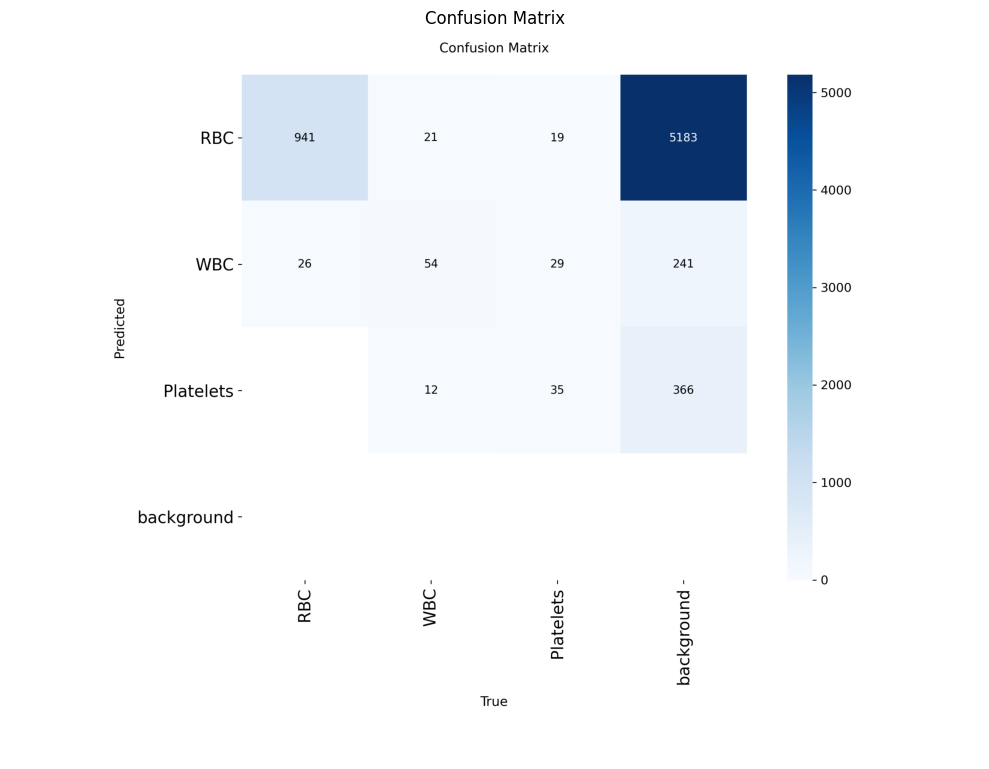

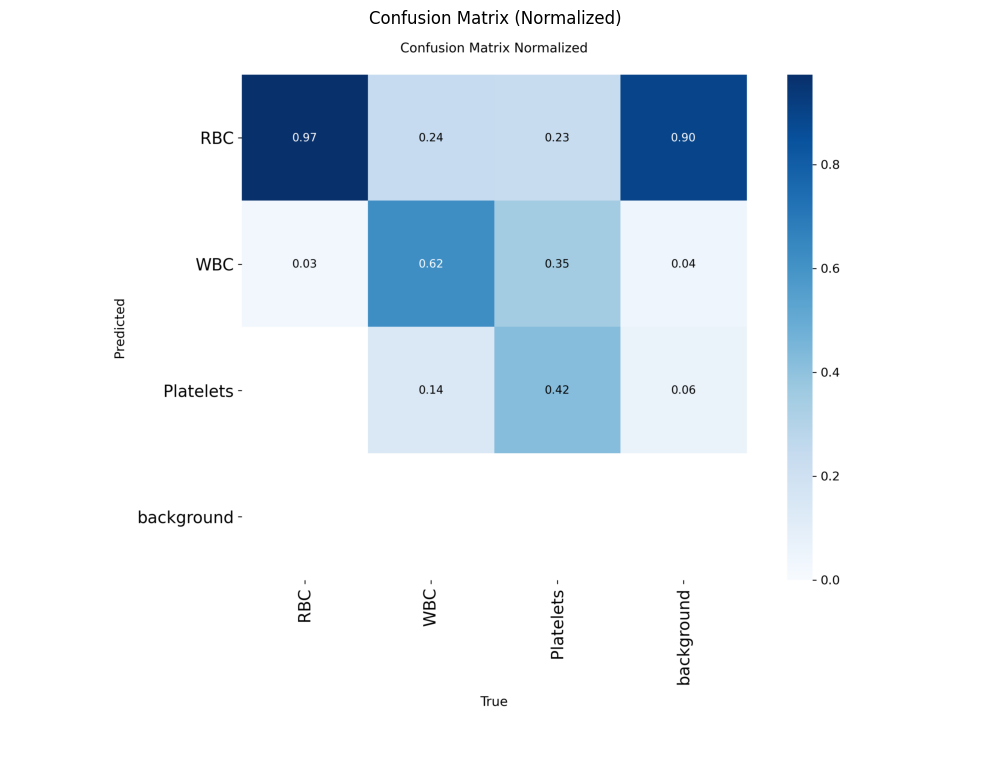

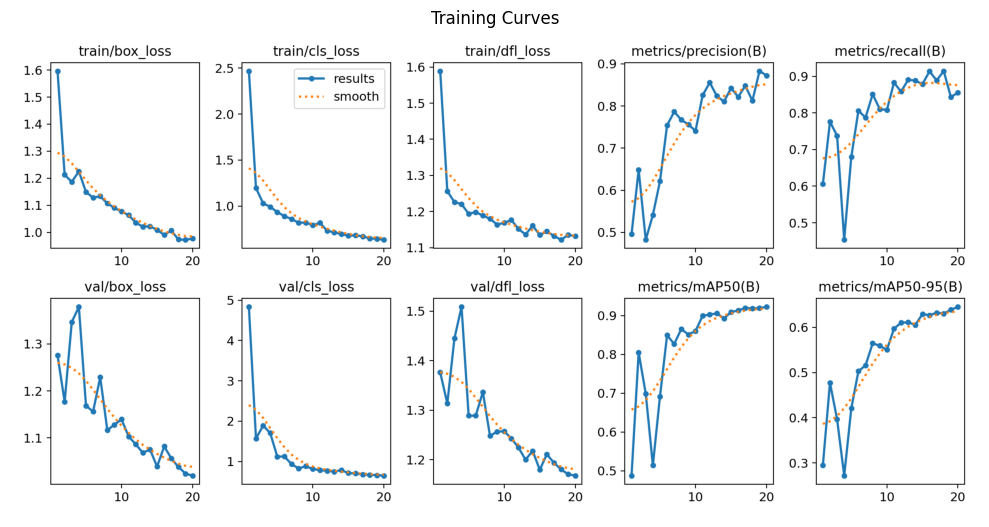

2026-10-01 11:12:40 | WARNING | Figure not found: /content/bccd_yolov8/runs/val/PR_curve.png


2026-10-01 11:12:40 | INFO    | Full log saved to /content/bccd_yolov8/experiment.log


INFO:bccd:Full log saved to /content/bccd_yolov8/experiment.log


2026-10-01 11:12:40 | INFO    | All artifacts are in /content/bccd_yolov8


INFO:bccd:All artifacts are in /content/bccd_yolov8


In [ ]:
val_dir = RUNS_DIR / "val"
train_dir = RUNS_DIR / "train"
figures = [
    (val_dir / "confusion_matrix.png", "Confusion Matrix"),
    (val_dir / "confusion_matrix_normalized.png", "Confusion Matrix (Normalized)"),
    (train_dir / "results.png", "Training Curves"),
    (val_dir / "PR_curve.png", "Precision-Recall Curve"),
]
for path, title in figures:
    if path.exists():
        plt.figure(figsize=(10, 8))
        plt.imshow(mpimg.imread(str(path)))
        plt.axis("off")
        plt.title(title)
        plt.tight_layout()
        plt.show()
    else:
        logger.warning("Figure not found: %s", path)

logger.info("Full log saved to %s", LOG_FILE)
logger.info("All artifacts are in %s", WORK_DIR)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
for p in sorted(Path("/content").rglob("*.png")):
    if "confusion_matrix" in p.name or p.name == "results.png" or p.name == "PR_curve.png":
        print(p)

/content/bccd_yolov8/runs/train/confusion_matrix.png
/content/bccd_yolov8/runs/train/confusion_matrix_normalized.png
/content/bccd_yolov8/runs/train/results.png
/content/bccd_yolov8/runs/val/confusion_matrix.png
/content/bccd_yolov8/runs/val/confusion_matrix_normalized.png


In [ ]:
from google.colab import files
files.download("/content/bccd_yolov8/runs/val/confusion_matrix_normalized.png")
files.download("/content/bccd_yolov8/runs/train/results.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
from pathlib import Path

s = json.loads(Path("/content/bccd_yolov8/results_summary.json").read_text())

print("| Split | Images | Boxes |")
print("|-------|--------|-------|")
for split in ("train", "val", "test"):
    d = s["dataset"][split]
    print(f"| {split.capitalize()} | {d['images']} | {d['boxes']} |")

print()
print(f"Training time: {s['train_minutes']} minutes")

print()
print("| Metric        | Value |")
print("|---------------|-------|")
print(f"| Precision     | {s['precision']:.3f} |")
print(f"| Recall        | {s['recall']:.3f} |")
print(f"| mAP@50        | {s['mAP50']:.3f} |")
print(f"| mAP@50-95     | {s['mAP50_95']:.3f} |")

print()
print("| Class     | AP@50 |")
print("|-----------|-------|")
for cls, ap in s["per_class_AP50"].items():
    print(f"| {cls} | {ap:.3f} |")

| Split | Images | Boxes |
|-------|--------|-------|
| Train | 205 | 2804 |
| Val | 87 | 1137 |
| Test | 72 | 945 |

Training time: 1.94 minutes

| Metric        | Value |
|---------------|-------|
| Precision     | 0.871 |
| Recall        | 0.855 |
| mAP@50        | 0.922 |
| mAP@50-95     | 0.647 |

| Class     | AP@50 |
|-----------|-------|
| RBC | 0.882 |
| WBC | 0.993 |
| Platelets | 0.892 |


In [ ]:
cm_run = best_model.val(
    data=str(data_yaml),
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    conf=0.25,
    project=str(RUNS_DIR),
    name="val_conf025",
    exist_ok=True,
    plots=True,
)

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 646.5±245.5 MB/s, size: 20.2 KB)
val: Scanning /content/bccd_yolov8/dataset/labels/val.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.9it/s 3.1s
                   all         87       1137      0.872      0.855      0.876      0.619
                   RBC         83        967      0.813      0.759      0.821      0.587
                   WBC         86         87      0.978          1      0.993       0.82
             Platelets         45         83      0.826      0.807      0.813      0.451
Speed: 3.9ms preprocess, 7.1ms inference, 0.0ms loss, 6.6ms postprocess per image
Results saved to /content/bccd_yolov8/runs/val_co